In [1]:
# Project 2: Data Collection and Cleaning

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset from an online source
df = sns.load_dataset('titanic')

print("Dataset collected successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Dataset collected successfully!
Rows: 891
Columns: 15


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
# Basic information
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Dataset Shape: (891, 15)

Column Names:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  

In [4]:
# Check missing values
missing_values = df.isnull().sum()

print("Missing Values:")
print(missing_values[missing_values > 0])

Missing Values:
age            177
embarked         2
deck           688
embark_town      2
dtype: int64


In [5]:
# Check duplicate rows
duplicates = df.duplicated().sum()

print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 107


In [6]:
# Step 3: Handle Missing Values and Duplicates

# Remove duplicate rows
df = df.drop_duplicates()

# Fill missing numerical values with median
df['age'] = df['age'].fillna(df['age'].median())

# Fill missing categorical values with mode
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])
df['embark_town'] = df['embark_town'].fillna(df['embark_town'].mode()[0])

# Drop deck because it has a large number of missing values
df = df.drop(columns=['deck'])

# Check missing values after cleaning
print("Missing values after cleaning:")
print(df.isnull().sum())

print("\nDuplicates after cleaning:", df.duplicated().sum())
print("\nCleaned dataset shape:", df.shape)

Missing values after cleaning:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

Duplicates after cleaning: 4

Cleaned dataset shape: (784, 14)


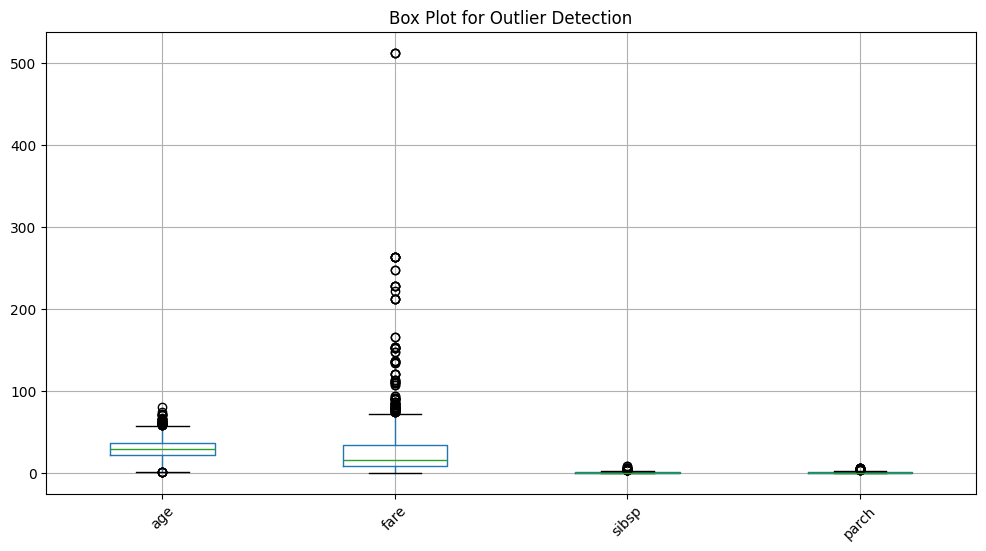

In [7]:
# Step 4A: Detect Outliers

numeric_cols = ['age', 'fare', 'sibsp', 'parch']

plt.figure(figsize=(12, 6))
df[numeric_cols].boxplot()
plt.title("Box Plot for Outlier Detection")
plt.xticks(rotation=45)
plt.show()

In [9]:
# Step 4B: Handle Outliers using IQR

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

print("Outliers handled using IQR method.")

Outliers handled using IQR method.


In [10]:
# Step 4C: Standardization

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_standardized = df.copy()
df_standardized[numeric_cols] = scaler.fit_transform(df[numeric_cols])

print("Standardization completed.")
df_standardized[numeric_cols].head()

Standardization completed.


,age,fare,sibsp,parch
0,-0.565647,-0.845924,0.776125,-0.543995
1,0.661944,1.969018,0.776125,-0.543995
2,-0.258749,-0.816251,-0.634030,-0.543995
3,0.431770,1.169669,0.776125,-0.543995
4,0.431770,-0.810756,-0.634030,-0.543995


In [11]:
# Step 4D: Normalization

from sklearn.preprocessing import MinMaxScaler

normalizer = MinMaxScaler()

df_normalized = df.copy()
df_normalized[numeric_cols] = normalizer.fit_transform(df[numeric_cols])

print("Normalization completed.")
df_normalized[numeric_cols].head()

Normalization completed.


,age,fare,sibsp,parch
0,0.375000,0.099046,0.4,0.0
1,0.660714,0.973837,0.4,0.0
2,0.446429,0.108267,0.0,0.0
3,0.607143,0.725426,0.4,0.0
4,0.607143,0.109975,0.0,0.0


In [12]:
# Step 4E: Save Cleaned Dataset

df.to_csv("Cleaned_Dataset.csv", index=False)

print("Cleaned dataset saved successfully!")
print("Final shape:", df.shape)

Cleaned dataset saved successfully!
Final shape: (784, 14)


In [13]:
# Final Data Quality Check

print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nFinal dataset shape:", df.shape)-

Missing values:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

Duplicate rows: 14

Final dataset shape: (784, 14)
